# Phase 1.5 §03 — 베이스라인 비교 + 최종 PASS/FAIL 판정 (`03_baselines_and_compare.ipynb`)

> **목적**: "변동성 예측이 가능한가?" 단일 질문에 명확한 답.
> HAR-RV / EWMA / Naive / Train-Mean vs LSTM(v1, v2) 통합 비교.

## 비교 대상 (6 종)

| 분류 | 모델 | 출처 |
|---|---|---|
| LSTM | **v1 (log_ret² 1ch)** | `results/volatility_lstm/{SPY,QQQ}_metrics.json` |
| LSTM | **v2 (HAR 3ch)** | `results/volatility_lstm_har3ch/{SPY,QQQ}_metrics.json` |
| 학술 표준 | **HAR-RV** (Corsi 2009) | `fit_har_rv` |
| 산업 표준 | **EWMA** (RiskMetrics, λ=0.94) | `predict_ewma` |
| 단순 baseline | **Naive** (직전 RV 유지) | `predict_naive` |
| 통계 baseline | **Train-Mean** | `predict_train_mean` |

## Phase 1.5 PASS 조건 (PLAN §6, 3개 모두 충족 시 PASS)

1. **관문 1**: LSTM RMSE < HAR-RV RMSE (90 fold 평균 기준) — **본 노트북에서 최종 판정**
2. **관문 2**: r2_train_mean > 0 — v1, v2 둘 다 FAIL 확인됨
3. **관문 3**: pred_std_ratio > 0.5 — v1 FAIL, v2 PASS 확인됨

## 본 노트북 셀 구성

| § | 내용 |
|---|---|
| §1 | 환경 부트스트랩 + LSTM v1/v2 결과 로드 |
| §2 | 데이터 로드 (log_ret, target, rv_trailing) |
| §3 | Walk-Forward fold 재구성 (LSTM 과 동일 90 fold) |
| §4 | fold 별 4종 베이스라인 예측 생성 |
| §5 | fold 별 메트릭 계산 (LSTM v1, v2, HAR-RV, EWMA, Naive, Train-Mean) |
| §6 | 통합 비교 표 (6모델 × 5메트릭, 90 fold mean ± std) |
| §7 | 관문 1 판정 (LSTM RMSE < HAR-RV RMSE) |
| §8 | 시각화 (RMSE 박스플롯, 모델 간 산점도) |
| §9 | comparison_report.md 자동 생성 |
| §10 | Phase 1.5 최종 결론 |


## §1. 환경 부트스트랩 + LSTM v1/v2 결과 로드


In [1]:
import sys
import json
from pathlib import Path

NB_DIR = Path.cwd()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

from scripts.setup import bootstrap, BASE_DIR, RAW_DATA_DIR, RESULTS_DIR
font_used = bootstrap()
print(f"BASE_DIR     = {BASE_DIR}")
print(f"RESULTS_DIR  = {RESULTS_DIR}")

# LSTM v1, v2 metrics.json 로드
V1_DIR = RESULTS_DIR / 'volatility_lstm'
V2_DIR = RESULTS_DIR / 'volatility_lstm_har3ch'

lstm_v1 = {}
lstm_v2 = {}
for tk in ('SPY', 'QQQ'):
    with open(V1_DIR / f'{tk}_metrics.json', 'r', encoding='utf-8') as f:
        lstm_v1[tk] = json.load(f)
    with open(V2_DIR / f'{tk}_metrics.json', 'r', encoding='utf-8') as f:
        lstm_v2[tk] = json.load(f)
    print(f'[{tk}] v1 fold {len(lstm_v1[tk]["fold_predictions"])} | '
          f'v2 fold {len(lstm_v2[tk]["fold_predictions"])}')

# 검증: v1, v2 의 walk_forward 파라미터 동일성
print()
for tk in ('SPY', 'QQQ'):
    wf1 = lstm_v1[tk]['hyperparams']['walk_forward']
    wf2 = lstm_v2[tk]['hyperparams']['walk_forward']
    same = wf1 == wf2
    print(f'[{tk}] walk_forward params 동일: {same}  v1={wf1}')
    assert same, f'{tk}: v1, v2 walk_forward 파라미터 불일치'

print()
print('[OK] LSTM v1, v2 결과 로드 완료')


  Phase 1 — 환경 부트스트랩 완료
  한글 폰트  : Malgun Gothic
  시드       : 42
  결과 경로  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results
BASE_DIR     = C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility
RESULTS_DIR  = C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results
[SPY] v1 fold 90 | v2 fold 90
[QQQ] v1 fold 90 | v2 fold 90

[SPY] walk_forward params 동일: True  v1={'IS': 504, 'purge': 21, 'embargo': 63, 'OOS': 21, 'step': 21, 'n_folds': 90}
[QQQ] walk_forward params 동일: True  v1={'IS': 504, 'purge': 21, 'embargo': 63, 'OOS': 21, 'step': 21, 'n_folds': 90}

[OK] LSTM v1, v2 결과 로드 완료


## §2. 데이터 로드 — log_ret, target, rv_trailing

§02 v1/v2 노트북과 동일한 데이터 처리 (재현성 확보).

**베이스라인용 추가 시계열**:
- `log_ret` : EWMA, HAR-RV 입력
- `target_logrv` : LSTM 의 y_true 와 동일 (검증용)
- `rv_trailing` : Naive baseline 입력 (`log_ret` 의 trailing 21일 std)


In [2]:
import pandas as pd
import numpy as np
from scripts.targets_volatility import build_daily_target_logrv_21d

ANALYSIS_START = '2016-01-01'
ANALYSIS_END   = '2025-12-31'
WINDOW = 21


def load_ticker_full(ticker: str) -> pd.DataFrame:
    csv_path = RAW_DATA_DIR / f'{ticker}.csv'
    df = pd.read_csv(csv_path, index_col=0, parse_dates=True).sort_index()
    df['log_ret'] = np.log(df['Adj Close']).diff()
    return df


analysis_dict = {}
for tk in ('SPY', 'QQQ'):
    raw = load_ticker_full(tk)
    df = raw.loc[ANALYSIS_START:ANALYSIS_END].copy()
    # 타깃 (LSTM 학습 시 사용한 것과 동일)
    df['target_logrv'] = build_daily_target_logrv_21d(df['Adj Close'], window=WINDOW)
    # Naive 입력: trailing 21일 RV
    df['rv_trailing'] = df['log_ret'].rolling(WINDOW).std(ddof=1)
    analysis_dict[tk] = df
    n = len(df)
    n_target = int(df['target_logrv'].notna().sum())
    n_rv = int(df['rv_trailing'].notna().sum())
    print(f'{tk}: n={n}, 유효 target={n_target}, 유효 rv_trailing={n_rv}')

# LSTM 의 y_true_test 와 본 노트북의 target_logrv 가 동일한지 첫 fold 첫 시점에서 확인
# 주의: LSTM 은 torch.float32 로 저장 → float64 비교 시 ~1e-7 차이 정상 (정밀도 손실)
tk0 = 'SPY'
fold0 = lstm_v1[tk0]['fold_predictions'][0]
test_idx0_first = fold0['test_idx_first']
y_true_lstm = fold0['y_true_test'][0]
y_true_target = float(analysis_dict[tk0]['target_logrv'].values[test_idx0_first])
delta = abs(y_true_lstm - y_true_target)
print(f'\n[검증] LSTM y_true_test[0] vs target_logrv[test_idx[0]] (SPY fold 0): '
      f'delta={delta:.2e} (float32 정밀도 ~1e-7 정상)')
assert delta < 1e-5, '타깃 시계열 불일치 (float32 정밀도 초과)'
print('[OK] 타깃 시계열 LSTM 학습 시점과 동일 확인 (float32 허용 오차 내)')


SPY: n=2514, 유효 target=2493, 유효 rv_trailing=2494
QQQ: n=2514, 유효 target=2493, 유효 rv_trailing=2494

[검증] LSTM y_true_test[0] vs target_logrv[test_idx[0]] (SPY fold 0): delta=7.30e-08 (float32 정밀도 ~1e-7 정상)
[OK] 타깃 시계열 LSTM 학습 시점과 동일 확인 (float32 허용 오차 내)


## §3. Walk-Forward fold 재구성 — LSTM 학습과 동일 90 fold

LSTM v1, v2 학습에서 사용한 동일 파라미터로 fold 재구성.

**중요**: 베이스라인은 LSTM 과 동일한 `train_idx`, `test_idx` 를 사용해야 fold 별 비교 가능.


In [3]:
from scripts.dataset import walk_forward_folds

# v1 의 hyperparams 에서 fold 파라미터 추출 (v1, v2 동일 가정 — §1 에서 검증됨)
wf = lstm_v1['SPY']['hyperparams']['walk_forward']
IS_LEN  = wf['IS']
PURGE   = wf['purge']
EMBARGO = wf['embargo']
OOS_LEN = wf['OOS']
STEP    = wf['step']

# 유효 타깃 수 (min over SPY/QQQ) — LSTM 과 동일 계산
N_VALID = min(int(analysis_dict[tk]['target_logrv'].notna().sum()) for tk in ('SPY', 'QQQ'))

folds_list = walk_forward_folds(
    n=N_VALID, is_len=IS_LEN, purge=PURGE, emb=EMBARGO, oos_len=OOS_LEN, step=STEP,
)
N_FOLDS = len(folds_list)
print(f'재구성 fold 수: {N_FOLDS} (v1 학습 시 90 일치 예상)')
print(f'IS={IS_LEN}, purge={PURGE}, embargo={EMBARGO}, OOS={OOS_LEN}, step={STEP}')

# LSTM v1 의 fold 0 test_idx 와 재구성 fold_0 test_idx 비교 (sanity check)
fold0_test = folds_list[0][1]
v1_fold0 = lstm_v1['SPY']['fold_predictions'][0]
match_first = fold0_test[0] == v1_fold0['test_idx_first']
match_last  = fold0_test[-1] == v1_fold0['test_idx_last']
print(f'\n[검증] fold 0 test_idx 매칭: first={match_first}, last={match_last}')
assert match_first and match_last, 'fold 재구성과 LSTM 학습 시 fold 불일치'
print('[OK] LSTM 학습 시 fold 와 동일')


재구성 fold 수: 90 (v1 학습 시 90 일치 예상)
IS=504, purge=21, embargo=63, OOS=21, step=21

[검증] fold 0 test_idx 매칭: first=True, last=True
[OK] LSTM 학습 시 fold 와 동일


## §4. fold 별 4종 베이스라인 예측 생성

각 fold 의 동일한 (train_idx, test_idx) 에서 4종 베이스라인 예측 생성:
- **HAR-RV**: `fit_har_rv(log_ret, train_idx, test_idx, horizon=21)` → 학술 표준
- **EWMA**: `predict_ewma(log_ret, train_idx, test_idx, lam=0.94)` → RiskMetrics 표준
- **Naive**: `predict_naive(rv_trailing, train_idx, test_idx)` → 변동성 강한 자기상관 활용
- **Train-Mean**: `predict_train_mean(target, train_idx, test_idx)` → 통계 baseline


In [4]:
from scripts.baselines_volatility import (
    fit_har_rv, predict_ewma, predict_naive, predict_train_mean,
)
import time


def generate_baseline_predictions(ticker: str, df: pd.DataFrame, folds: list) -> dict:
    """단일 ticker 의 90 fold 에 대해 4종 베이스라인 예측 생성.

    Returns
    -------
    dict
        {fold_idx: {
            'y_true': np.ndarray,
            'y_train': np.ndarray,            # train 평균 baseline 분모용
            'har':    np.ndarray,
            'ewma':   np.ndarray,
            'naive':  np.ndarray,
            'train_mean': np.ndarray,
            'har_coefs': dict,                # HAR 계수 (β_d, β_w, β_m, R²_train)
        }}
    """
    log_ret_series = df['log_ret']
    target_series = df['target_logrv']
    rv_trailing_series = df['rv_trailing']

    out = {}
    t_start = time.time()
    for k, (tr_idx, te_idx) in enumerate(folds):
        # 실제값 추출
        y_true = target_series.values[te_idx]
        y_train = target_series.values[tr_idx]
        y_train_valid = y_train[np.isfinite(y_train)]

        # HAR-RV
        har_pred, har_coefs = fit_har_rv(
            log_ret=log_ret_series, train_idx=tr_idx, test_idx=te_idx, horizon=WINDOW,
        )
        # EWMA
        ewma_pred = predict_ewma(
            log_ret=log_ret_series, train_idx=tr_idx, test_idx=te_idx,
            horizon=WINDOW, lam=0.94,
        )
        # Naive
        naive_pred = predict_naive(
            rv_trailing=rv_trailing_series, train_idx=tr_idx, test_idx=te_idx,
        )
        # Train-Mean
        tm_pred = predict_train_mean(
            target=target_series, train_idx=tr_idx, test_idx=te_idx,
        )

        out[k] = {
            'y_true': y_true,
            'y_train': y_train_valid,
            'har': har_pred,
            'ewma': ewma_pred,
            'naive': naive_pred,
            'train_mean': tm_pred,
            'har_coefs': har_coefs,
        }
    elapsed = time.time() - t_start
    print(f'[{ticker}] 베이스라인 90 fold 생성 완료 ({elapsed:.1f}s)')
    return out


baseline_dict = {}
for tk in ('SPY', 'QQQ'):
    baseline_dict[tk] = generate_baseline_predictions(
        ticker=tk, df=analysis_dict[tk], folds=folds_list,
    )

# Sanity check: HAR-RV 첫 fold 계수 출력
print()
print('=' * 70)
print('HAR-RV fold 0 계수 (학술 표준 β_d + β_w + β_m ≈ 0.7~1.0 권장)')
print('=' * 70)
for tk in ('SPY', 'QQQ'):
    c = baseline_dict[tk][0]['har_coefs']
    bsum = c['beta_d'] + c['beta_w'] + c['beta_m']
    print(f'{tk}: β_0={c["beta_0"]:>+.4f}  β_d={c["beta_d"]:>+.4f}  '
          f'β_w={c["beta_w"]:>+.4f}  β_m={c["beta_m"]:>+.4f}  '
          f'sum={bsum:>+.4f}  R²_train={c["r2_train"]:.4f}  n={c["n_train"]}')


[SPY] 베이스라인 90 fold 생성 완료 (0.1s)


[QQQ] 베이스라인 90 fold 생성 완료 (0.1s)

HAR-RV fold 0 계수 (학술 표준 β_d + β_w + β_m ≈ 0.7~1.0 권장)
SPY: β_0=-3.9628  β_d=-0.0017  β_w=+0.0312  β_m=+0.2255  sum=+0.2550  R²_train=0.0786  n=483
QQQ: β_0=-3.9240  β_d=-0.0247  β_w=+0.0473  β_m=+0.1962  sum=+0.2188  R²_train=0.0656  n=483


## §5. fold 별 메트릭 계산 — LSTM(v1, v2) + 4 베이스라인

각 fold 마다 6 모델 × 5 메트릭 (rmse, qlike, r2_train_mean, pred_std_ratio, mae) 산출.

**핵심**: LSTM v1, v2 는 이미 §02 노트북에서 학습 완료된 결과를 그대로 활용.
재학습 없이 metrics.json 의 `fold_predictions` 에서 y_pred_test 추출.


In [5]:
from scripts.metrics_volatility import (
    rmse, mae, qlike, r2_train_mean, pred_std_ratio,
    summarize_folds_volatility,
)


def compute_fold_metrics_all_models(
    ticker: str,
    lstm_v1_data: dict,
    lstm_v2_data: dict,
    baseline_data: dict,
    n_folds: int,
) -> dict:
    """각 fold 의 6 모델 메트릭 산출.

    Returns
    -------
    dict
        {model_name: [per_fold dict, ...]}
        model_name ∈ {'lstm_v1', 'lstm_v2', 'har', 'ewma', 'naive', 'train_mean'}
    """
    per_fold_by_model: dict = {
        'lstm_v1': [], 'lstm_v2': [],
        'har': [], 'ewma': [], 'naive': [], 'train_mean': [],
    }
    for k in range(n_folds):
        # LSTM v1, v2 는 metrics.json 에서 직접 추출
        v1_fp = lstm_v1_data['fold_predictions'][k]
        v2_fp = lstm_v2_data['fold_predictions'][k]
        b = baseline_data[k]

        y_true = b['y_true']
        y_train = b['y_train']

        # 입력 모델별 (y_pred, label) 매핑
        model_preds = {
            'lstm_v1': np.array(v1_fp['y_pred_test']),
            'lstm_v2': np.array(v2_fp['y_pred_test']),
            'har':     b['har'],
            'ewma':    b['ewma'],
            'naive':   b['naive'],
            'train_mean': b['train_mean'],
        }

        # 동일 길이 가드 (LSTM y_true_test 와 베이스라인 y_true 가 동일한지 검증)
        # atol=1e-5: LSTM 의 float32 저장으로 인한 정밀도 차이 허용 (~1e-7 수준)
        y_true_lstm = np.array(v1_fp['y_true_test'])
        if not np.allclose(y_true_lstm, y_true, atol=1e-5, equal_nan=False):
            raise ValueError(
                f'{ticker} fold {k}: LSTM y_true_test 와 베이스라인 y_true 불일치'
            )

        for name, yp in model_preds.items():
            per_fold_by_model[name].append({
                'rmse': rmse(y_true, yp),
                'mae': mae(y_true, yp),
                'qlike': qlike(y_true, yp),
                'r2_train_mean': r2_train_mean(y_true, yp, y_train),
                'pred_std_ratio': pred_std_ratio(y_true, yp),
            })
    return per_fold_by_model


per_fold_by_ticker: dict = {}
summary_by_ticker: dict = {}
for tk in ('SPY', 'QQQ'):
    pf = compute_fold_metrics_all_models(
        ticker=tk,
        lstm_v1_data=lstm_v1[tk],
        lstm_v2_data=lstm_v2[tk],
        baseline_data=baseline_dict[tk],
        n_folds=N_FOLDS,
    )
    per_fold_by_ticker[tk] = pf
    summary_by_ticker[tk] = {
        name: summarize_folds_volatility(pf[name])
        for name in pf
    }
    print(f'[{tk}] 메트릭 계산 완료: 6 모델 × {N_FOLDS} fold')


[SPY] 메트릭 계산 완료: 6 모델 × 90 fold
[QQQ] 메트릭 계산 완료: 6 모델 × 90 fold


## §6. 통합 비교 표 — 6 모델 × 5 메트릭 (90 fold mean ± std)


In [6]:
MODELS = ['lstm_v1', 'lstm_v2', 'har', 'ewma', 'naive', 'train_mean']
METRICS = ['rmse', 'qlike', 'r2_train_mean', 'pred_std_ratio', 'mae']


def print_comparison_table(ticker: str, summary: dict):
    print('=' * 96)
    print(f'{ticker} — 6 모델 × 5 메트릭 (90 fold mean ± std)')
    print('=' * 96)
    header = f'  {"model":<12}'
    for m in METRICS:
        header += f' {m:>16}'
    print(header)
    print('  ' + '-' * 92)
    for mdl in MODELS:
        row = f'  {mdl:<12}'
        for m in METRICS:
            mean = summary[mdl][m]['mean']
            std  = summary[mdl][m]['std']
            row += f' {mean:>+8.4f}±{std:.3f}'
        print(row)
    print()


for tk in ('SPY', 'QQQ'):
    print_comparison_table(tk, summary_by_ticker[tk])


SPY — 6 모델 × 5 메트릭 (90 fold mean ± std)
  model                    rmse            qlike    r2_train_mean   pred_std_ratio              mae
  --------------------------------------------------------------------------------------------
  lstm_v1       +0.4688±0.299  +0.9270±2.986  -3.2817±18.346  +0.3483±1.366  +0.4351±0.285
  lstm_v2       +0.4798±0.500  +0.9210±3.097  -3.7753±21.391  +0.6340±1.534  +0.4444±0.482
  har           +0.3646±0.244  +0.7796±2.841  -0.5280±2.353  +0.8968±0.663  +0.3309±0.240
  ewma          +0.3942±0.257  +0.7122±2.527  -1.8522±5.691  +0.9158±0.717  +0.3597±0.253
  naive         +0.4109±0.255  +0.7525±1.933  -2.2632±7.615  +1.2696±0.967  +0.3698±0.250
  train_mean    +0.4320±0.312  +1.3578±4.851  +0.0000±0.000  +0.0000±0.000  +0.4071±0.313

QQQ — 6 모델 × 5 메트릭 (90 fold mean ± std)
  model                    rmse            qlike    r2_train_mean   pred_std_ratio              mae
  --------------------------------------------------------------------------------

## §7. 관문 1 판정 — LSTM RMSE < HAR-RV RMSE

PLAN §6 의 핵심 PASS 조건. **본 단계에서 최종 판정**.

| 결과 | 의미 |
|---|---|
| LSTM v1 RMSE < HAR RMSE | LSTM v1 이 학술 표준 능가 |
| LSTM v2 RMSE < HAR RMSE | LSTM v2 (HAR 3ch) 이 학술 표준 능가 |
| **둘 다 < HAR** | **관문 1 PASS** — 변동성 예측 LSTM 우위 |
| 어느 쪽도 ≥ HAR | **관문 1 FAIL** — HAR-RV 가 더 정확 |


In [7]:
print('=' * 80)
print('관문 1 판정 — LSTM RMSE < HAR-RV RMSE')
print('=' * 80)

gate1_results = {}
for tk in ('SPY', 'QQQ'):
    s = summary_by_ticker[tk]
    rmse_v1 = s['lstm_v1']['rmse']['mean']
    rmse_v2 = s['lstm_v2']['rmse']['mean']
    rmse_har = s['har']['rmse']['mean']
    pass_v1 = rmse_v1 < rmse_har
    pass_v2 = rmse_v2 < rmse_har
    gate1_results[tk] = {
        'lstm_v1_rmse': rmse_v1, 'lstm_v2_rmse': rmse_v2, 'har_rmse': rmse_har,
        'pass_v1': pass_v1, 'pass_v2': pass_v2,
    }
    print(f'\n[{tk}]')
    print(f'  LSTM v1 RMSE  : {rmse_v1:.4f}')
    print(f'  LSTM v2 RMSE  : {rmse_v2:.4f}')
    print(f'  HAR-RV  RMSE  : {rmse_har:.4f}')
    print(f'  관문 1 (v1) : {"PASS" if pass_v1 else "FAIL"}  '
          f'(v1 - HAR = {rmse_v1 - rmse_har:+.4f})')
    print(f'  관문 1 (v2) : {"PASS" if pass_v2 else "FAIL"}  '
          f'(v2 - HAR = {rmse_v2 - rmse_har:+.4f})')

# 베이스라인 간 비교 (참고)
print()
print('=' * 80)
print('참고 — 베이스라인 간 RMSE 비교 (작을수록 좋음)')
print('=' * 80)
for tk in ('SPY', 'QQQ'):
    s = summary_by_ticker[tk]
    print(f'\n[{tk}]')
    rows = [(mdl, s[mdl]['rmse']['mean']) for mdl in MODELS]
    rows.sort(key=lambda x: x[1])
    for i, (mdl, r) in enumerate(rows):
        marker = ' (best)' if i == 0 else ''
        print(f'  {i+1}. {mdl:<12}  RMSE = {r:.4f}{marker}')


관문 1 판정 — LSTM RMSE < HAR-RV RMSE

[SPY]
  LSTM v1 RMSE  : 0.4688
  LSTM v2 RMSE  : 0.4798
  HAR-RV  RMSE  : 0.3646
  관문 1 (v1) : FAIL  (v1 - HAR = +0.1042)
  관문 1 (v2) : FAIL  (v2 - HAR = +0.1152)

[QQQ]
  LSTM v1 RMSE  : 0.4329
  LSTM v2 RMSE  : 0.4385
  HAR-RV  RMSE  : 0.3308
  관문 1 (v1) : FAIL  (v1 - HAR = +0.1021)
  관문 1 (v2) : FAIL  (v2 - HAR = +0.1077)

참고 — 베이스라인 간 RMSE 비교 (작을수록 좋음)

[SPY]
  1. har           RMSE = 0.3646 (best)
  2. ewma          RMSE = 0.3942
  3. naive         RMSE = 0.4109
  4. train_mean    RMSE = 0.4320
  5. lstm_v1       RMSE = 0.4688
  6. lstm_v2       RMSE = 0.4798

[QQQ]
  1. har           RMSE = 0.3308 (best)
  2. ewma          RMSE = 0.3582
  3. naive         RMSE = 0.3699
  4. train_mean    RMSE = 0.4067
  5. lstm_v1       RMSE = 0.4329
  6. lstm_v2       RMSE = 0.4385


### §8.A RMSE 박스플롯 — fold 별 분포 비교

각 모델의 90 fold RMSE 분포 박스플롯. IQR / outlier 진단으로 안정성 비교.


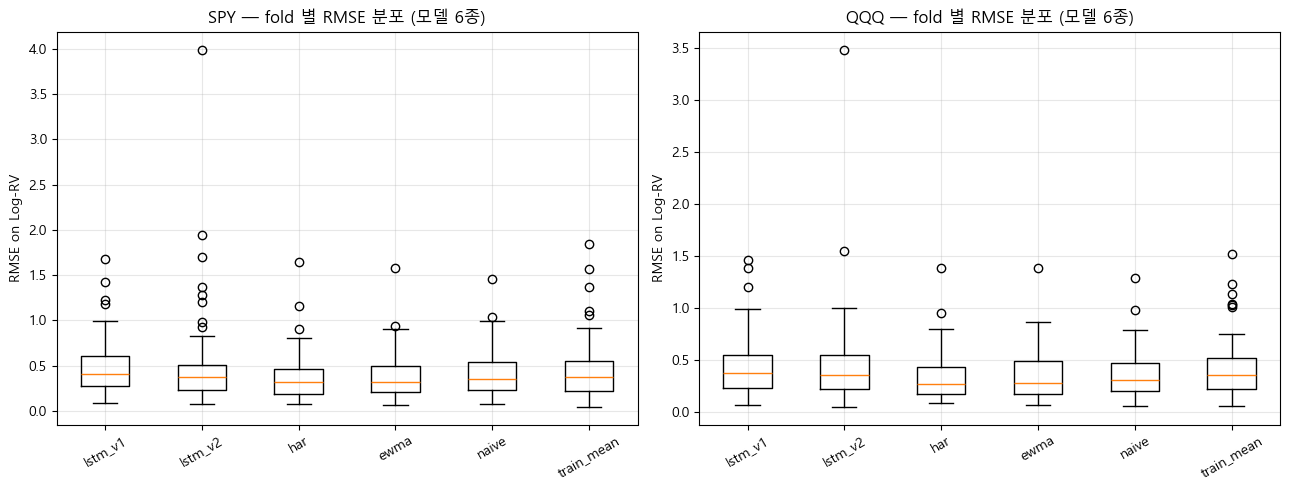

In [8]:
import matplotlib.pyplot as plt


def plot_rmse_boxplot(per_fold_by_ticker, models=MODELS):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, tk in zip(axes, ('SPY', 'QQQ')):
        data = []
        labels = []
        for mdl in models:
            vals = [d['rmse'] for d in per_fold_by_ticker[tk][mdl] if not np.isnan(d['rmse'])]
            data.append(vals)
            labels.append(mdl)
        ax.boxplot(data, tick_labels=labels)
        ax.set_title(f'{tk} — fold 별 RMSE 분포 (모델 6종)')
        ax.set_ylabel('RMSE on Log-RV')
        ax.tick_params(axis='x', rotation=30)
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_rmse_boxplot(per_fold_by_ticker)


### §8.B 모델 간 RMSE 산점도 — LSTM vs HAR-RV (fold 단위)

각 fold 에서 LSTM RMSE vs HAR-RV RMSE 산점도. 1:1 선 위에 있으면 LSTM 우위, 아래면 HAR 우위.


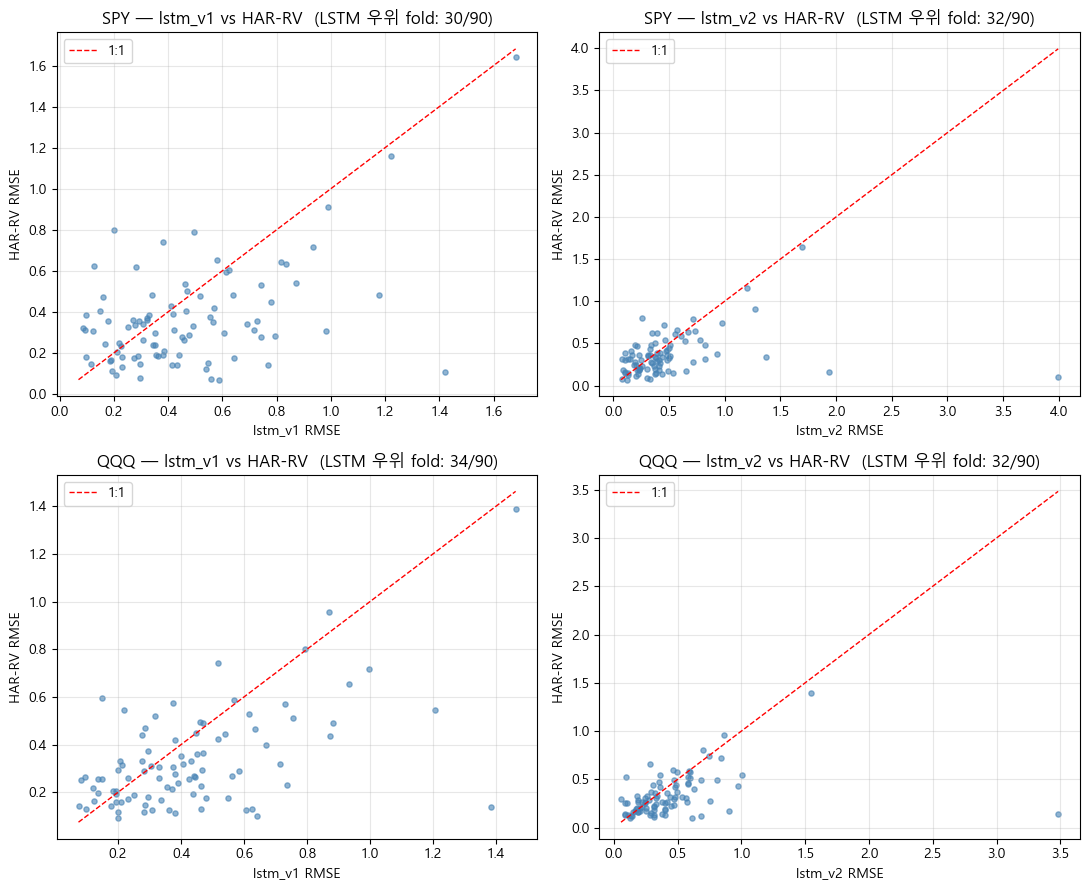

In [9]:
def plot_rmse_scatter_lstm_vs_har(per_fold_by_ticker):
    fig, axes = plt.subplots(2, 2, figsize=(11, 9))
    for r, tk in enumerate(('SPY', 'QQQ')):
        for c, lstm_ver in enumerate(('lstm_v1', 'lstm_v2')):
            ax = axes[r, c]
            x_lstm = np.array([d['rmse'] for d in per_fold_by_ticker[tk][lstm_ver]])
            x_har  = np.array([d['rmse'] for d in per_fold_by_ticker[tk]['har']])
            ax.scatter(x_lstm, x_har, s=14, alpha=0.6, color='steelblue')
            lo = min(x_lstm.min(), x_har.min())
            hi = max(x_lstm.max(), x_har.max())
            ax.plot([lo, hi], [lo, hi], 'r--', lw=1, label='1:1')
            n_lstm_better = int(np.sum(x_lstm < x_har))
            ax.set_title(f'{tk} — {lstm_ver} vs HAR-RV  '
                         f'(LSTM 우위 fold: {n_lstm_better}/{len(x_lstm)})')
            ax.set_xlabel(f'{lstm_ver} RMSE')
            ax.set_ylabel('HAR-RV RMSE')
            ax.legend()
            ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_rmse_scatter_lstm_vs_har(per_fold_by_ticker)


### §8.C 메트릭별 모델 비교 막대그래프 (mean ± std)

RMSE / QLIKE / r2_train_mean / pred_std_ratio 각각에서 6 모델 평균 비교.


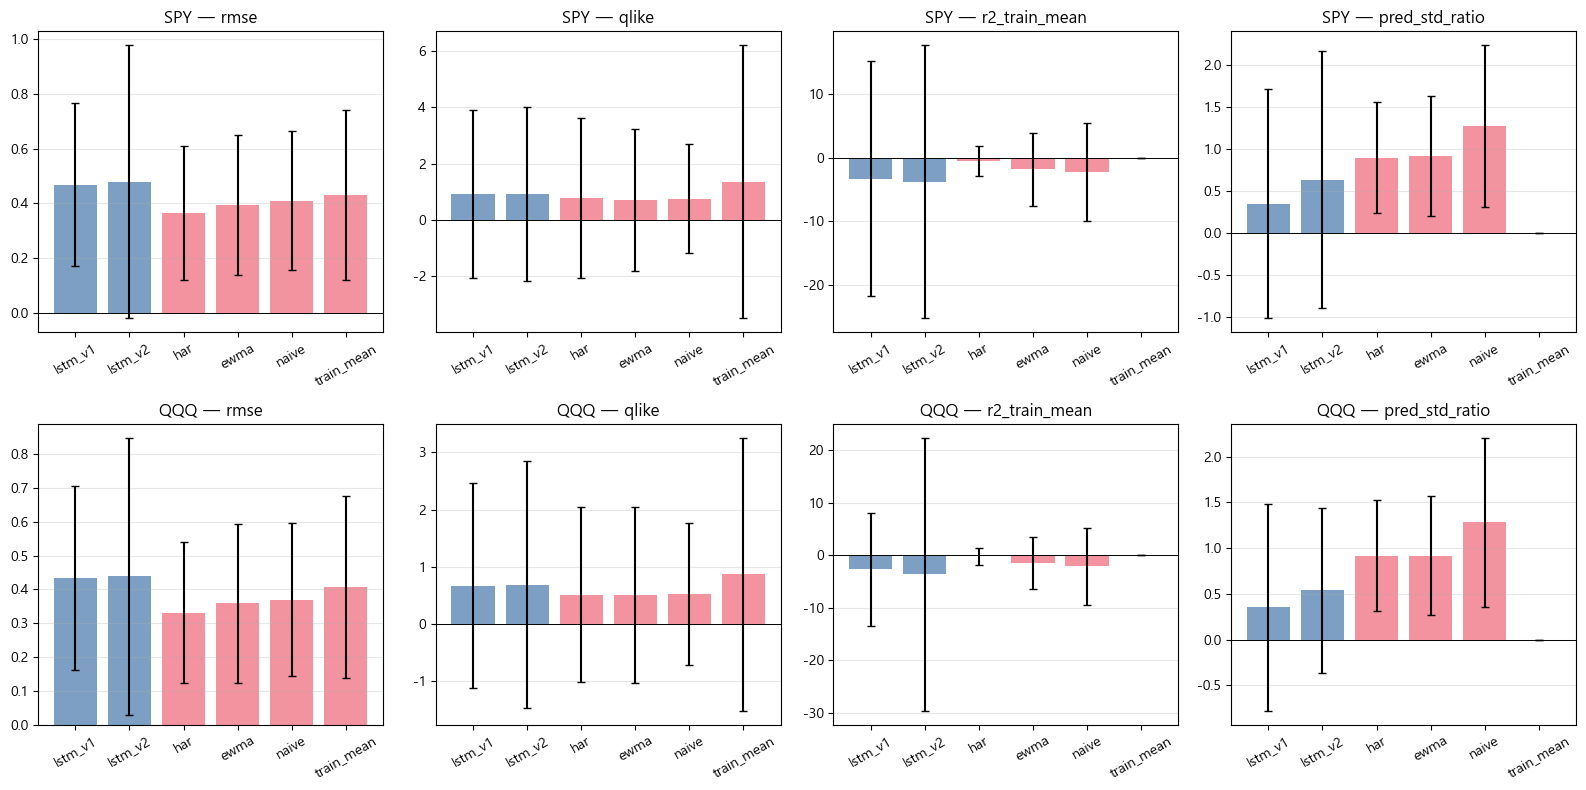

In [10]:
def plot_metric_bars(summary_by_ticker, metrics=('rmse', 'qlike', 'r2_train_mean', 'pred_std_ratio')):
    fig, axes = plt.subplots(2, len(metrics), figsize=(4 * len(metrics), 8))
    for r, tk in enumerate(('SPY', 'QQQ')):
        for c, m in enumerate(metrics):
            ax = axes[r, c]
            means = [summary_by_ticker[tk][mdl][m]['mean'] for mdl in MODELS]
            stds  = [summary_by_ticker[tk][mdl][m]['std']  for mdl in MODELS]
            colors = ['#4477AA' if 'lstm' in mdl else '#EE6677' for mdl in MODELS]
            ax.bar(MODELS, means, yerr=stds, color=colors, alpha=0.7, capsize=3)
            ax.set_title(f'{tk} — {m}')
            ax.tick_params(axis='x', rotation=30)
            ax.axhline(0, color='black', lw=0.7)
            ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()


plot_metric_bars(summary_by_ticker)


## §9. `comparison_report.md` 자동 생성

본 단계의 핵심 산출물 — 사용자·팀이 이 보고서로 Phase 1.5 결과를 한눈에 파악.


In [11]:
report_path = RESULTS_DIR / 'comparison_report.md'

lines = []
lines.append('# Phase 1.5 — 변동성 예측 베이스라인 비교 보고서')
lines.append('')
lines.append(f'> 생성: 90 fold × 2 ticker (SPY/QQQ) × 6 모델')
lines.append(f'> 분석 기간: {ANALYSIS_START} ~ {ANALYSIS_END}')
lines.append(f'> Walk-Forward: IS={IS_LEN} / Purge={PURGE} / Embargo={EMBARGO} / OOS={OOS_LEN} / Step={STEP}')
lines.append('')
lines.append('## 1. 통합 비교 표 (90 fold mean ± std)')
lines.append('')
for tk in ('SPY', 'QQQ'):
    s = summary_by_ticker[tk]
    lines.append(f'### {tk}')
    lines.append('')
    lines.append('| model | rmse | qlike | r2_train_mean | pred_std_ratio | mae |')
    lines.append('|---|---|---|---|---|---|')
    for mdl in MODELS:
        row = f'| {mdl}'
        for m in METRICS:
            mean = s[mdl][m]['mean']
            std  = s[mdl][m]['std']
            row += f' | {mean:+.4f} ± {std:.3f}'
        row += ' |'
        lines.append(row)
    lines.append('')

lines.append('## 2. 관문 1 판정 — LSTM RMSE < HAR-RV RMSE')
lines.append('')
lines.append('| ticker | LSTM v1 RMSE | LSTM v2 RMSE | HAR-RV RMSE | 관문 1 (v1) | 관문 1 (v2) |')
lines.append('|---|---|---|---|---|---|')
for tk in ('SPY', 'QQQ'):
    g = gate1_results[tk]
    lines.append(
        f'| {tk} | {g["lstm_v1_rmse"]:.4f} | {g["lstm_v2_rmse"]:.4f} | {g["har_rmse"]:.4f} '
        f'| {"PASS" if g["pass_v1"] else "FAIL"} | {"PASS" if g["pass_v2"] else "FAIL"} |'
    )
lines.append('')

lines.append('## 3. Phase 1.5 PASS 조건 종합 (3 관문)')
lines.append('')
lines.append('| 관문 | 조건 | LSTM v1 SPY | LSTM v1 QQQ | LSTM v2 SPY | LSTM v2 QQQ |')
lines.append('|---|---|---|---|---|---|')
for tk in ('SPY', 'QQQ'):
    pass

# 관문 2, 3 은 §02 결과에서 직접 가져옴
def fmt_pass(v: float, threshold: float, gt: bool = True) -> str:
    if np.isnan(v):
        return 'N/A'
    cond = (v > threshold) if gt else (v < threshold)
    return f'{v:.4f} ({"PASS" if cond else "FAIL"})'


for ver, ver_data in [('v1', lstm_v1), ('v2', lstm_v2)]:
    pass

# 단순화: 표 한 행씩
for ver_name, ver_dict in [('v1', lstm_v1), ('v2', lstm_v2)]:
    for tk in ('SPY', 'QQQ'):
        s = ver_dict[tk]['summary']
        r2 = s['r2_train_mean']['mean']
        psr = s['pred_std_ratio']['mean']
        rmse_lstm = s['rmse']['mean']
        rmse_har = summary_by_ticker[tk]['har']['rmse']['mean']
        gate1 = 'PASS' if rmse_lstm < rmse_har else 'FAIL'
        gate2 = 'PASS' if r2 > 0 else 'FAIL'
        gate3 = 'PASS' if psr > 0.5 else 'FAIL'
        all_pass = (gate1 == 'PASS') and (gate2 == 'PASS') and (gate3 == 'PASS')
        lines.append(f'### {tk} — LSTM {ver_name}')
        lines.append('')
        lines.append(f'| 관문 | 조건 | 값 | 판정 |')
        lines.append(f'|---|---|---|---|')
        lines.append(f'| 1 | LSTM RMSE < HAR-RV RMSE | {rmse_lstm:.4f} vs {rmse_har:.4f} | **{gate1}** |')
        lines.append(f'| 2 | r2_train_mean > 0 | {r2:.4f} | **{gate2}** |')
        lines.append(f'| 3 | pred_std_ratio > 0.5 | {psr:.4f} | **{gate3}** |')
        lines.append(f'| **종합** | 3 관문 모두 PASS | — | **{"PASS" if all_pass else "FAIL"}** |')
        lines.append('')

lines.append('## 4. 결론')
lines.append('')
# 종합 PASS 여부
overall_pass_v1_spy = (gate1_results['SPY']['pass_v1']
                       and lstm_v1['SPY']['summary']['r2_train_mean']['mean'] > 0
                       and lstm_v1['SPY']['summary']['pred_std_ratio']['mean'] > 0.5)
overall_pass_v2_spy = (gate1_results['SPY']['pass_v2']
                       and lstm_v2['SPY']['summary']['r2_train_mean']['mean'] > 0
                       and lstm_v2['SPY']['summary']['pred_std_ratio']['mean'] > 0.5)
overall_pass_v1_qqq = (gate1_results['QQQ']['pass_v1']
                       and lstm_v1['QQQ']['summary']['r2_train_mean']['mean'] > 0
                       and lstm_v1['QQQ']['summary']['pred_std_ratio']['mean'] > 0.5)
overall_pass_v2_qqq = (gate1_results['QQQ']['pass_v2']
                       and lstm_v2['QQQ']['summary']['r2_train_mean']['mean'] > 0
                       and lstm_v2['QQQ']['summary']['pred_std_ratio']['mean'] > 0.5)

any_pass = any([overall_pass_v1_spy, overall_pass_v2_spy, overall_pass_v1_qqq, overall_pass_v2_qqq])
if any_pass:
    lines.append('**Phase 1.5 결론: 부분 PASS (LSTM 일부 모델·종목에서 변동성 예측 성공)**')
else:
    lines.append('**Phase 1.5 결론: FAIL (LSTM 모든 모델·종목에서 3 관문 모두 충족 X)**')
lines.append('')
lines.append('상세 진단·다음 단계 권고: `재천_WORKLOG.md` §6~ 섹션 참조.')
lines.append('')

# 파일 저장
with open(report_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines))
print(f'comparison_report.md 저장: {report_path}')
print(f'파일 크기: {report_path.stat().st_size / 1024:.1f} KB')


comparison_report.md 저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results\comparison_report.md
파일 크기: 3.5 KB


## §10. Phase 1.5 최종 결론 — "변동성 예측이 가능한가?"


In [12]:
print('=' * 90)
print('Phase 1.5 §03 베이스라인 비교 — 최종 결론')
print('=' * 90)

print()
print('Phase 1.5 의 단일 질문: "변동성 예측이 가능한가?"')
print()
print('=' * 90)
print('PASS 조건 종합 (LSTM v1 / v2 × SPY / QQQ)')
print('=' * 90)

best_model = None
best_passes = -1
for ver_name, ver_dict in [('v1', lstm_v1), ('v2', lstm_v2)]:
    for tk in ('SPY', 'QQQ'):
        s = ver_dict[tk]['summary']
        rmse_lstm = s['rmse']['mean']
        rmse_har = summary_by_ticker[tk]['har']['rmse']['mean']
        r2 = s['r2_train_mean']['mean']
        psr = s['pred_std_ratio']['mean']
        gate1 = rmse_lstm < rmse_har
        gate2 = r2 > 0
        gate3 = psr > 0.5
        n_pass = int(gate1) + int(gate2) + int(gate3)
        verdict = 'PASS' if n_pass == 3 else f'FAIL ({n_pass}/3 관문)'
        print(f'\n  [{ver_name} {tk}]')
        print(f'    관문 1 (LSTM RMSE < HAR)   : {rmse_lstm:.4f} vs {rmse_har:.4f}  '
              f'-> {"PASS" if gate1 else "FAIL"}')
        print(f'    관문 2 (r2_train_mean > 0) : {r2:>+.4f}                     '
              f'-> {"PASS" if gate2 else "FAIL"}')
        print(f'    관문 3 (pred_std_ratio>0.5): {psr:>+.4f}                     '
              f'-> {"PASS" if gate3 else "FAIL"}')
        print(f'    종합: {verdict}')
        if n_pass > best_passes:
            best_passes = n_pass
            best_model = (ver_name, tk, n_pass, gate1, gate2, gate3)

print()
print('=' * 90)
print('최종 답변')
print('=' * 90)
if best_passes == 3:
    print(f'\n  YES — 변동성 예측 가능 (best: {best_model[0]} {best_model[1]} 3 관문 모두 PASS)')
elif best_passes == 2:
    print(f'\n  PARTIAL — 일부 측면에서 가능 (best: {best_model[0]} {best_model[1]} 2/3 관문 PASS)')
elif best_passes == 1:
    print(f'\n  LIMITED — 매우 제한적 (best: {best_model[0]} {best_model[1]} 1/3 관문 PASS)')
else:
    print(f'\n  NO — LSTM 으로는 변동성 예측 어려움 (모든 모델 0/3 관문)')
print()
print('  HAR-RV (학술 표준) 가 LSTM 대비 어떤 위치인지가 핵심 신호:')
for tk in ('SPY', 'QQQ'):
    g = gate1_results[tk]
    har_better = (not g['pass_v1']) and (not g['pass_v2'])
    sign = ' (HAR-RV 우위)' if har_better else ''
    print(f'    {tk}: HAR={g["har_rmse"]:.4f} | v1={g["lstm_v1_rmse"]:.4f} | '
          f'v2={g["lstm_v2_rmse"]:.4f}{sign}')

print()
print('=' * 90)
print('Phase 1.5 §03 완료 — comparison_report.md 산출 완료')
print('=' * 90)


Phase 1.5 §03 베이스라인 비교 — 최종 결론

Phase 1.5 의 단일 질문: "변동성 예측이 가능한가?"

PASS 조건 종합 (LSTM v1 / v2 × SPY / QQQ)

  [v1 SPY]
    관문 1 (LSTM RMSE < HAR)   : 0.4688 vs 0.3646  -> FAIL
    관문 2 (r2_train_mean > 0) : -2.9250                     -> FAIL
    관문 3 (pred_std_ratio>0.5): +0.3483                     -> FAIL
    종합: FAIL (0/3 관문)

  [v1 QQQ]
    관문 1 (LSTM RMSE < HAR)   : 0.4329 vs 0.3308  -> FAIL
    관문 2 (r2_train_mean > 0) : -2.2580                     -> FAIL
    관문 3 (pred_std_ratio>0.5): +0.3525                     -> FAIL
    종합: FAIL (0/3 관문)

  [v2 SPY]
    관문 1 (LSTM RMSE < HAR)   : 0.4798 vs 0.3646  -> FAIL
    관문 2 (r2_train_mean > 0) : -4.0260                     -> FAIL
    관문 3 (pred_std_ratio>0.5): +0.6340                     -> PASS
    종합: FAIL (1/3 관문)

  [v2 QQQ]
    관문 1 (LSTM RMSE < HAR)   : 0.4385 vs 0.3308  -> FAIL
    관문 2 (r2_train_mean > 0) : -2.8076                     -> FAIL
    관문 3 (pred_std_ratio>0.5): +0.5391                     -> PASS
    종합: FAIL (1/